## Rekurencyjne sieci neuronowe

In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

In [26]:
symbol = 'AAPL'
data = yf.download(symbol, start='2010-01-01', end='2023-12-31')

prices = data[['Close']]
prices = prices.dropna()

print(prices.head())
plt.show()

[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          AAPL
2010-01-04  6.406480
2010-01-05  6.417557
2010-01-06  6.315475
2010-01-07  6.303802
2010-01-08  6.345710


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

prices_scaled = pd.DataFrame(scaled_prices, index=prices.index, columns=prices.columns)

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length, 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

sequence_length = 50
X, y = create_sequences(scaled_prices, sequence_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [28]:
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(sequence_length, 1)),Dense(1)
])

model.compile(optimizer='adam', loss='mse')
print(model.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [29]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.5975e-05 - val_loss: 6.3550e-04
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.7674e-05 - val_loss: 8.3217e-04
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.7345e-05 - val_loss: 7.2879e-04
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3857e-05 - val_loss: 7.5368e-04
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.7984e-05 - val_loss: 9.8637e-04
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5094e-05 - val_loss: 0.0011
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.7397e-05 - val_loss: 6.0041e-04
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1893e-05 - val_loss: 6.0503e-04
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.7829e-05 - val_loss: 8.1452e-04
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8684e-05 - val_loss: 5

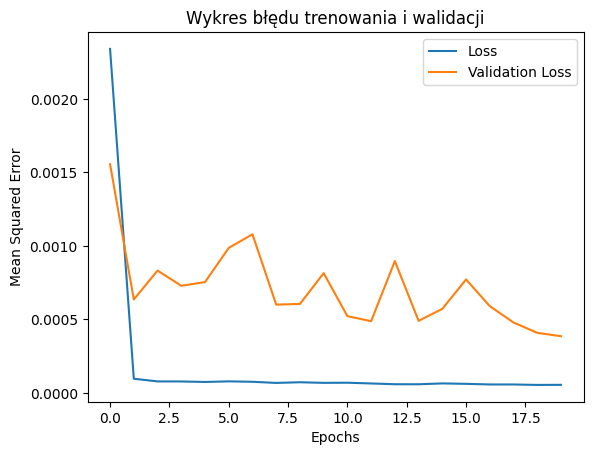

In [30]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Wykres błędu trenowania i walidacji')
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


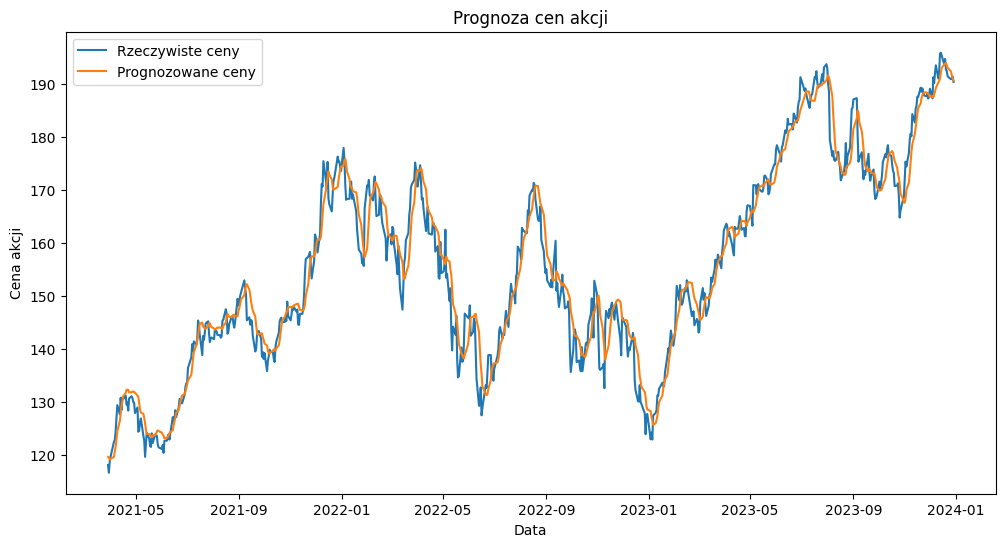

In [31]:
predicted_prices = model.predict(X_test)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_prices_rescaled = scaler.inverse_transform(predicted_prices)
plt.figure(figsize=(12, 6))
plt.plot(prices.index[-len(y_test):], y_test_rescaled, label='Rzeczywiste ceny')
plt.plot(prices.index[-len(y_test):], predicted_prices_rescaled, label='Prognozowane ceny')
plt.legend()
plt.title('Prognoza cen akcji')
plt.xlabel('Data')
plt.ylabel('Cena akcji')
plt.show()

In [34]:
window_sizes = [30, 50, 100]
results_windows = {}
for seq_len in window_sizes:
    print(f"\n Okno czasowe: {seq_len} ")
    
    X_tmp, y_tmp = create_sequences(scaled_prices, seq_len)
    X_tmp = X_tmp.reshape((X_tmp.shape[0], X_tmp.shape[1], 1))
    
    train_size = int(len(X_tmp) * 0.8)
    X_train_tmp, X_test_tmp = X_tmp[:train_size], X_tmp[train_size:]
    y_train_tmp, y_test_tmp = y_tmp[:train_size], y_tmp[train_size:]
    model_tmp = Sequential([
        LSTM(50, return_sequences=False, input_shape=(seq_len, 1)),
        Dense(1)
    ])
    model_tmp.compile(optimizer='adam', loss='mse')
    
    history_tmp = model_tmp.fit(
        X_train_tmp, y_train_tmp,
        epochs=10,
        batch_size=32,
        validation_data=(X_test_tmp, y_test_tmp),
        verbose=0
    )
    

    y_pred_tmp = model_tmp.predict(X_test_tmp)
    mse_tmp = mean_squared_error(y_test_tmp, y_pred_tmp)
    results_windows[seq_len] = mse_tmp
    print(f"MSE dla okna {seq_len}: {mse_tmp:.6f}")

print("\nMSE dla różnych długości okna:")
for seq_len, mse in results_windows.items():
    print(f"Okno {seq_len}: MSE = {mse:.6f}")


 Okno czasowe: 30 


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MSE dla okna 30: 0.000543

 Okno czasowe: 50 


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MSE dla okna 50: 0.000527

 Okno czasowe: 100 


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MSE dla okna 100: 0.000747

MSE dla różnych długości okna:
Okno 30: MSE = 0.000543
Okno 50: MSE = 0.000527
Okno 100: MSE = 0.000747


In [37]:
from tensorflow.keras.layers import SimpleRNN, GRU


X_arch, y_arch = create_sequences(scaled_prices, sequence_length)
X_arch = X_arch.reshape((X_arch.shape[0], X_arch.shape[1], 1))

train_size_arch = int(len(X_arch) * 0.8)
X_train_arch, X_test_arch = X_arch[:train_size_arch], X_arch[train_size_arch:]
y_train_arch, y_test_arch = y_arch[:train_size_arch], y_arch[train_size_arch:]

def build_and_evaluate(model_type, input_shape):
    model = Sequential()
    if model_type == "SimpleRNN":
        model.add(SimpleRNN(50, input_shape=input_shape))
    elif model_type == "LSTM":
        model.add(LSTM(50, input_shape=input_shape))
    elif model_type == "GRU":
        model.add(GRU(50, input_shape=input_shape))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        X_train_arch, y_train_arch,
        epochs=10,
        batch_size=32,
        validation_data=(X_test_arch, y_test_arch),
        verbose=0
    )
    
    y_pred = model.predict(X_test_arch)
    mse = mean_squared_error(y_test_arch, y_pred)
    return mse, history

architectures = ["SimpleRNN", "LSTM", "GRU"]
results_arch = {}

for arch in architectures:
    print(f"\nArchitektura: {arch}")
    mse_arch, history_arch = build_and_evaluate(arch, (sequence_length, 1))
    results_arch[arch] = mse_arch
    print(f"MSE (test) dla {arch}: {mse_arch:.6f}")

print("\nPodsumowanie MSE dla architektur (okno =", sequence_length, ")")
for arch, mse in results_arch.items():
    print(f"{arch}: MSE = {mse:.6f}")


Architektura: SimpleRNN


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MSE (test) dla SimpleRNN: 0.005008

Architektura: LSTM


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MSE (test) dla LSTM: 0.000890

Architektura: GRU


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MSE (test) dla GRU: 0.000334

Podsumowanie MSE dla architektur (okno = 50 )
SimpleRNN: MSE = 0.005008
LSTM: MSE = 0.000890
GRU: MSE = 0.000334
